In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:

df = pd.read_csv("messy_ecommerce_sales_data.csv")
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


So we have no null values for id, Customer_Name, Order_ID, Order_Date, Product, payment_mehtod and Status 

then we have null values for : 

 - category : 8 null values
 - Quantity : 5 null values
 - Price    : 5 null values
 - Total    : 14 null values 

In [5]:
df.describe()

,ID,Total
count,103.000000,89.000000
mean,149.640777,1232.949101
std,28.704326,2605.471455
min,100.000000,-20000.000000
25%,125.500000,582.130000
50%,149.000000,1138.760000
75%,174.500000,2153.400000
max,199.000000,4722.700000


In [233]:
#Removing those rows where column total is missing 103-14 elements are removed 89 records now 
df= df.dropna(subset = ["Total"])
df.info()
df= df.copy()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 99
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              86 non-null     int64         
 1   Customer_Name   86 non-null     object        
 2   Order_ID        86 non-null     object        
 3   Order_Date      86 non-null     datetime64[ns]
 4   Product         86 non-null     object        
 5   Category        86 non-null     object        
 6   Quantity        86 non-null     float64       
 7   Price           86 non-null     float64       
 8   Payment_Method  86 non-null     object        
 9   Status          86 non-null     object        
 10  Total           86 non-null     float64       
 11  Month           86 non-null     int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(6)
memory usage: 8.4+ KB


In [9]:

#INCONSISTENCIES IN THE COLUMN NAME 
for col in df.columns:
    print(f"'{col}'")

'ID'
' Customer_Name'
'Order_ID'
'Order_Date'
'Product'
' Category'
'Quantity'
'Price'
'Payment_Method'
'Status'
'Total'


In [11]:
# this removes any extra space in the column name 
df.columns = df.columns.str.strip()


In [235]:
df["Category"] = df["Category"].fillna("Unknown")
df = df.copy()
#We have some Nan values for categories so we fill it with unknown to maintain consistency 


In [ ]:
df

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              89 non-null     int64  
 1   Customer_Name   89 non-null     object 
 2   Order_ID        89 non-null     object 
 3   Order_Date      89 non-null     object 
 4   Product         89 non-null     object 
 5   Category        89 non-null     object 
 6   Quantity        89 non-null     object 
 7   Price           89 non-null     object 
 8   Payment_Method  89 non-null     object 
 9   Status          89 non-null     object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 8.3+ KB


In [237]:
#MORE DATA CONSISTENCY 

df["Category"] = df["Category"].str.upper().str.strip()
df["Product"]= df["Product"].str.upper().str.strip()
df["Payment_Method"] = df["Payment_Method"].str.upper().str.strip()
df["Status"] = df["Status"].str.upper().str.strip()
df = df.copy()

In [ ]:
df

In [19]:
#THE DIFFERENT PRODUCTS BEING SOLD LIST
df["Product"].unique()


array(['BLENDER', 'TENNIS RACKET', 'SCIENCE', 'BIOGRAPHY', 'COMICS',
       'SHOES', 'FICTION', 'SMARTPHONE', 'BASKETBALL', 'MICROWAVE',
       'VACUUM', 'LAMP', 'YOGA MAT', 'T-SHIRT', 'SMARTWATCH',
       'HEADPHONES', 'FOOTBALL', 'LAPTOP', 'JACKET', 'JEANS'],
      dtype=object)

In [21]:
#DIFFERENT CATEEGORIES OF PRODUCTS BEING SOLD LIST
df["Category"].unique()

array(['HOME', 'SPORTS', 'BOOKS', 'CLOTHING', 'ELECTRONICS', 'ELECTRONIC',
       'UNKNOWN'], dtype=object)

In [23]:
#DIFFERENT PAYEMENT METHOD LIST 
df["Payment_Method"].unique()

array(['CASH ON DELIVERY', 'PAYPAL', 'CREDIT CARD', 'BANK TRANSFER'],
      dtype=object)

In [239]:
#changing the data type of price and quantity to int from 
df["Price"] = df["Price"].astype(float) 
df["Quantity"] = df["Quantity"].astype(float)
df["Total"] = df["Total"].astype(float) 
df=df.copy()

In [ ]:
df

In [241]:
#CHECK WEATHER TOTAL CALCULATION IS DONE CORRECTLY 
df["Total"] = df["Quantity"]* df["Price"]
df=df.copy()
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total,Month
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,ELECTRONICS,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00,11
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05,12
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60,3
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51,10
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18,11
...,...,...,...,...,...,...,...,...,...,...,...,...
94,194,Customer_194,ORD-69764,2025-02-10,LAMP,HOME,5.0,944.54,CASH ON DELIVERY,RETURNED,4722.70,2
95,195,Customer_195,ORD-82876,2025-06-19,BIOGRAPHY,BOOKS,5.0,817.46,CASH ON DELIVERY,RETURNED,4087.30,6
97,197,Customer_197,ORD-79139,2025-06-23,BLENDER,ELECTRONICS,1.0,160.16,PAYPAL,CANCELLED,160.16,6
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,ELECTRONICS,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02,7


In [29]:
df[df['ID'] == 111]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
11,111,Customer_111,ORD-72349,10/22/2025,COMICS,BOOKS,2.0,865.77,CREDIT CARD,RETURNED,1731.54


In [243]:
#MAKING SURE DATE IS IN PERFECT DATE TIME ORDER 
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed')
df = df.copy()

In [33]:
#check for duplicate order_id's 
df["Order_ID"].duplicated().sum()

3

In [35]:
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,HOME,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,UNKNOWN,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02
99,199,Customer_199,ORD-82922,2025-01-22,BLENDER,HOME,5.0,372.28,CREDIT CARD,SHIPPED,1861.40
100,175,Customer_175,ORD-56651,2025-02-24,HEADPHONES,ELECTRONICS,1.0,111.36,CREDIT CARD,PROCESSING,111.36
101,142,Customer_142,ORD-69018,2025-10-30,SHOES,CLOTHING,5.0,645.26,CREDIT CARD,SHIPPED,3226.30


In [245]:
#to drop duplicates 
df.drop_duplicates(subset=["Order_ID"],inplace = True)
df= df.copy()

In [39]:
df["Order_ID"].duplicated().sum()

0

In [247]:
#making negative values positive we are going to use .abs()- absolute values removes the
#negative sign and makes any number postive 
df["Quantity"] = df["Quantity"]. abs()
df = df.copy()

In [ ]:
df

In [249]:
df["Total"] = df["Quantity"] * df["Price"] 
df = df.copy()

In [45]:
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,HOME,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18
...,...,...,...,...,...,...,...,...,...,...,...
94,194,Customer_194,ORD-69764,2025-02-10,LAMP,HOME,5.0,944.54,CASH ON DELIVERY,RETURNED,4722.70
95,195,Customer_195,ORD-82876,2025-06-19,BIOGRAPHY,BOOKS,5.0,817.46,CASH ON DELIVERY,RETURNED,4087.30
97,197,Customer_197,ORD-79139,2025-06-23,BLENDER,HOME,1.0,160.16,PAYPAL,CANCELLED,160.16
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,UNKNOWN,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02


In [49]:
df.to_csv("messyData.csv", index = False)

In [ ]:
df

In [51]:
# ONE FINAL PREVIEW 

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              86 non-null     int64         
 1   Customer_Name   86 non-null     object        
 2   Order_ID        86 non-null     object        
 3   Order_Date      86 non-null     datetime64[ns]
 4   Product         86 non-null     object        
 5   Category        86 non-null     object        
 6   Quantity        86 non-null     float64       
 7   Price           86 non-null     float64       
 8   Payment_Method  86 non-null     object        
 9   Status          86 non-null     object        
 10  Total           86 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 8.1+ KB


In [53]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,HOME,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18


In [55]:
df.tail()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
94,194,Customer_194,ORD-69764,2025-02-10,LAMP,HOME,5.0,944.54,CASH ON DELIVERY,RETURNED,4722.70
95,195,Customer_195,ORD-82876,2025-06-19,BIOGRAPHY,BOOKS,5.0,817.46,CASH ON DELIVERY,RETURNED,4087.30
97,197,Customer_197,ORD-79139,2025-06-23,BLENDER,HOME,1.0,160.16,PAYPAL,CANCELLED,160.16
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,UNKNOWN,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02
99,199,Customer_199,ORD-82922,2025-01-22,BLENDER,HOME,5.0,372.28,CREDIT CARD,SHIPPED,1861.40


In [57]:
df.sample(5)


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
62,162,Customer_162,ORD-27743,2025-05-19,BLENDER,HOME,2.0,155.76,CREDIT CARD,RETURNED,311.52
25,125,Customer_125,ORD-23202,2025-02-09,COMICS,BOOKS,4.0,765.69,PAYPAL,SHIPPED,3062.76
33,133,Customer_133,ORD-68182,2024-12-05,BIOGRAPHY,UNKNOWN,5.0,343.24,CREDIT CARD,SHIPPED,1716.20
27,127,Customer_127,ORD-65482,2025-05-12,BLENDER,HOME,5.0,336.02,BANK TRANSFER,RETURNED,1680.10
28,128,Customer_128,ORD-12270,2024-11-10,LAMP,ELECTRONICS,3.0,898.69,BANK TRANSFER,DELIVERED,2696.07


In [59]:
#checking missing values 
df.isnull().sum()

ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [63]:
df.duplicated().sum()

0

In [67]:
df.describe()


,ID,Order_Date,Quantity,Price,Total
count,86.000000,86,86.000000,86.000000,86.000000
mean,149.906977,2025-04-10 10:02:47.441860352,3.011628,619.457674,1780.133953
min,100.000000,2023-01-05 00:00:00,1.000000,-100.000000,-300.000000
25%,127.250000,2025-01-30 06:00:00,2.000000,268.800000,669.912500
50%,149.500000,2025-05-14 00:00:00,3.000000,534.705000,1300.930000
75%,173.750000,2025-07-28 00:00:00,4.000000,740.400000,2377.430000
max,199.000000,2025-11-06 00:00:00,5.000000,10000.000000,20000.000000
std,28.063218,NaN,1.506802,1057.617754,2315.858530


In [71]:
negative_rows = df[df["Quantity"]<=0]
negative_rows

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [251]:
df["Category"] = df["Category"].replace({
    "ELECTRONIC": "ELECTRONICS"
})
df = df.copy()

In [75]:
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,HOME,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18
...,...,...,...,...,...,...,...,...,...,...,...
94,194,Customer_194,ORD-69764,2025-02-10,LAMP,HOME,5.0,944.54,CASH ON DELIVERY,RETURNED,4722.70
95,195,Customer_195,ORD-82876,2025-06-19,BIOGRAPHY,BOOKS,5.0,817.46,CASH ON DELIVERY,RETURNED,4087.30
97,197,Customer_197,ORD-79139,2025-06-23,BLENDER,HOME,1.0,160.16,PAYPAL,CANCELLED,160.16
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,UNKNOWN,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02


I REALIZED THAT HEADPHONES COMES UNDER ELECTRONICS, SO DOES SMARTPHONES AND LAPTOPS, JEANS VACCUM SHOES, BIOGRAPHY, SO I'M GOING TO FIX THAT

In [174]:
df.loc[df["Product"] =="HEADPHONES", "Category"] = "ELECTRONICS"
df.loc[df["Product"] =="SMARTPHONE", "Category"] = "ELECTRONICS"
df.loc[df["Product"] =="LAPTOP", "Category"] = "ELECTRONICS"
df.loc[df["Product"]=="VACUUM", "Category"] ="ELECTRONICS"
df.loc[df["Product"]=="BLENDER", "Category"] ="ELECTRONICS"

df.loc[df["Product"]=="JEANS", "Category"] ="CLOTHING"
df.loc[df["Product"]=="SHOES", "Category"] = "SPORTS"
df.loc[df["Product"] =="BIOGRAPHY", "Category"]="BOOKS"
df.loc[df["Product"] =="YOGA MAT", "Category"] ="SPORTS"
df.loc[df["Product"] =="BASKETBALL", "Category"] ="SPORTS"
df.loc[df["Product"] =="LAMP", "Category"] ="HOME"
df.loc[df["Product"]=="T-SHIRT", "Category"] ="CLOTHING"

# ANALYSIS PLAN 
BASIC OVERVIEW 
- TELL MOST COMMON CATEGORY SHOPPED IN
- THEN THE MOST USED PAYMENT METHOD
- TELL HOW MANY RETURNS/ CANCELLATIONS DONE 

df.describe()

In [80]:
#TELL MOST COMMON CATEGORY SHOPPED IN
df["Category"] .value_counts()

Category
BOOKS          21
HOME           17
ELECTRONICS    17
SPORTS         13
CLOTHING       11
UNKNOWN         7
Name: count, dtype: int64

most common catefory shopped in is Books with the least shopped 
category being clothing and 7 unknown category 


In [85]:
#THEN THE MOST USED PAYMENT METHOD
df["Payment_Method"].value_counts()

Payment_Method
CASH ON DELIVERY    29
PAYPAL              20
BANK TRANSFER       19
CREDIT CARD         18
Name: count, dtype: int64

Most common mode of payement was cash on delivery and least being credit card delivery 


In [91]:
#HOW MANY RETURNS/CANCELLATIONS DONE 
df["Status"].value_counts()

Status
RETURNED      24
SHIPPED       20
PROCESSING    20
CANCELLED     12
DELIVERED     10
Name: count, dtype: int64

out of 34 orders that were diliverd and ship majority of the order was return 

TOTAL REVENUE ANALYSIS 
- TOTAL REVENUE MADE BY THE BUSINESS 
- MOST PROFITABLE CATEGORY 
- LEAST PROFITABLE CATEGORY 


In [99]:
#Total revenue made by the business 
df["Total"].sum()

153091.52000000002

In [101]:
#which category makes the most money 
df.groupby("Category")["Total"].sum().sort_values(ascending= False)

Category
ELECTRONICS    38640.20
BOOKS          38357.11
CLOTHING       26859.92
HOME           24429.71
SPORTS         17736.25
UNKNOWN         7068.33
Name: Total, dtype: float64

Most profitable category is Electronics and least  few unknown 
Categories 

In [117]:
#Top selling products 
df.groupby(["Product","Category"])["Quantity"].sum().sort_values(ascending = False)

Product        Category   
SCIENCE        BOOKS          24.0
BLENDER        HOME           21.0
LAMP           HOME           20.0
COMICS         BOOKS          20.0
SHOES          CLOTHING       19.0
BIOGRAPHY      BOOKS          13.0
TENNIS RACKET  SPORTS         13.0
FICTION        BOOKS          12.0
T-SHIRT        CLOTHING       10.0
MICROWAVE      HOME           10.0
BASKETBALL     SPORTS          9.0
SMARTWATCH     ELECTRONICS     8.0
YOGA MAT       SPORTS          8.0
JACKET         CLOTHING        8.0
FOOTBALL       SPORTS          7.0
SMARTPHONE     ELECTRONICS     7.0
JEANS          CLOTHING        5.0
BIOGRAPHY      UNKNOWN         5.0
LAPTOP         ELECTRONICS     4.0
MICROWAVE      ELECTRONICS     4.0
VACUUM         HOME            4.0
SHOES          UNKNOWN         4.0
JEANS          UNKNOWN         4.0
LAMP           ELECTRONICS     3.0
VACUUM         ELECTRONICS     3.0
T-SHIRT        ELECTRONICS     2.0
VACUUM         UNKNOWN         2.0
BASKETBALL     ELECTRONICS  

In [ ]:
df.to_csv("messyData.csv", index = False)

NOW I HAVE TO RECHECK FEW OF THE PREVIOUS ANALYSIS AGAIN TO MAKE SURE WE HAVE PROPER RESULTS

In [176]:
#CHECK WHICH CATEGORY WAS MOST SOLD AND WHICH WAS LEAST 
df["Category"] .value_counts()

Category
ELECTRONICS    25
SPORTS         22
BOOKS          22
HOME           10
CLOTHING        7
Name: count, dtype: int64

MOST SOLD CATEGORY HAPPEND TO BE A TIE BETWEEN ELECTRONICS AND BOOKS 
LEAST SOLD CATEGORY WAS = CLOTHING 

In [178]:
#which category makes the most money 
df.groupby("Category")["Total"].sum().sort_values(ascending= False)

Category
ELECTRONICS    44617.55
BOOKS          40073.31
SPORTS         34142.46
HOME           18430.03
CLOTHING       15828.17
Name: Total, dtype: float64

THE CATEOGRY WHICH MADE THE MOST MONEY - ELECTRONICS AND LEAST IS CLOTHING 

In [192]:
#Top selling products 
df.groupby(["Product","Category"])["Quantity"].sum().sort_values(ascending = False)

Product        Category   
SCIENCE        BOOKS          24.0
BLENDER        ELECTRONICS    23.0
SHOES          SPORTS         23.0
LAMP           HOME           23.0
COMICS         BOOKS          20.0
BIOGRAPHY      BOOKS          18.0
TENNIS RACKET  SPORTS         13.0
FICTION        BOOKS          12.0
T-SHIRT        CLOTHING       12.0
BASKETBALL     SPORTS         11.0
MICROWAVE      HOME           10.0
VACUUM         ELECTRONICS     9.0
YOGA MAT       SPORTS          9.0
JEANS          CLOTHING        9.0
SMARTPHONE     ELECTRONICS     8.0
SMARTWATCH     ELECTRONICS     8.0
JACKET         CLOTHING        8.0
FOOTBALL       SPORTS          7.0
LAPTOP         ELECTRONICS     6.0
MICROWAVE      ELECTRONICS     4.0
HEADPHONES     ELECTRONICS     2.0
Name: Quantity, dtype: float64

SO THE MOST SOLD PRODUCT IS SCIENCE BOOK CLOSELY FOLLOWED BY BLENDER 
AND LEAST SOLD ITEM HAPPEND TO BE HEADPHONES 


RETURNS AND CANCELLATIONS MADE 

In [195]:
df["Status"].value_counts()

Status
RETURNED      24
SHIPPED       20
PROCESSING    20
CANCELLED     12
DELIVERED     10
Name: count, dtype: int64

In [199]:
#revenue lost due to returns 
reveue_lost = df[df["Status"] =="RETURNED"]["Total"].sum()
reveue_lost

38477.22

revenue lost due to returns = 38477.22

TIME BASED ANALYSIS 

In [253]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.month
df.groupby("Month")["Total"].sum().sort_values(ascending = False)
df = df.copy()

MOST SAME WAS MADE IN THE MONTH OF FEB AND LEAST ITEMS WERE SOLD IN THE MOTH OF APRIL

  #                 VISUALISATIONS 

In [263]:
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total,Month
0,100,Customer_100,ORD-41285,2024-11-22,BLENDER,ELECTRONICS,3.0,38.00,CASH ON DELIVERY,SHIPPED,114.00,11
2,102,Customer_102,ORD-84355,2024-12-23,TENNIS RACKET,SPORTS,1.0,389.05,PAYPAL,DELIVERED,389.05,12
3,103,Customer_103,ORD-57811,2025-03-19,SCIENCE,BOOKS,5.0,233.92,PAYPAL,PROCESSING,1169.60,3
4,104,Customer_104,ORD-93614,2025-10-20,BIOGRAPHY,BOOKS,1.0,552.51,CASH ON DELIVERY,PROCESSING,552.51,10
5,105,Customer_105,ORD-22442,2024-11-20,TENNIS RACKET,SPORTS,3.0,122.06,CASH ON DELIVERY,CANCELLED,366.18,11
...,...,...,...,...,...,...,...,...,...,...,...,...
94,194,Customer_194,ORD-69764,2025-02-10,LAMP,HOME,5.0,944.54,CASH ON DELIVERY,RETURNED,4722.70,2
95,195,Customer_195,ORD-82876,2025-06-19,BIOGRAPHY,BOOKS,5.0,817.46,CASH ON DELIVERY,RETURNED,4087.30,6
97,197,Customer_197,ORD-79139,2025-06-23,BLENDER,ELECTRONICS,1.0,160.16,PAYPAL,CANCELLED,160.16,6
98,198,Customer_198,ORD-14608,2025-07-27,VACUUM,ELECTRONICS,2.0,497.01,CASH ON DELIVERY,SHIPPED,994.02,7


# CATEGORY DISTRIBUTION 
### 1. What people buy the most?

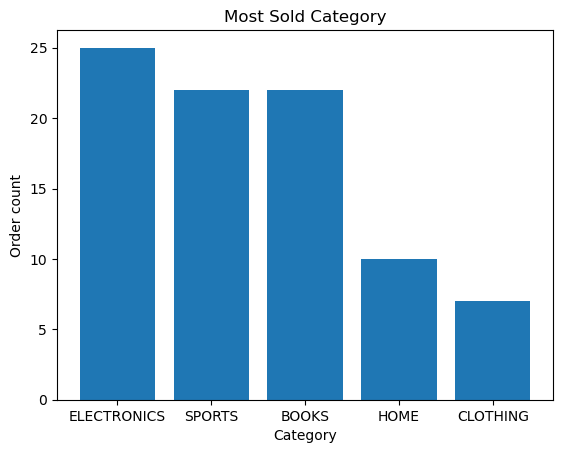

In [313]:
category = df["Category"].value_counts()
category
name = df["Category"].unique()

plt.bar(name,category)
plt.xlabel("Category")
plt.ylabel("Order count")
plt.title("Most Sold Category")
plt.show()


# REVENUE BY CATEGORY 
### 2. Which category makes the most money?

Text(0.5, 1.0, 'Total across different categories')

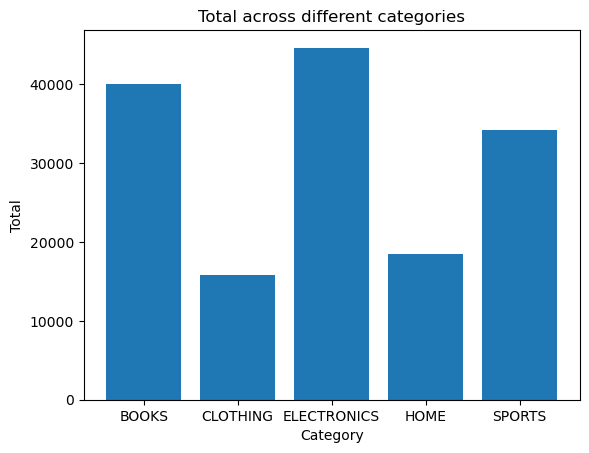

In [362]:

group_data = df.groupby("Category")["Total"].sum()
names = group_data.index
total = group_data.values

plt.bar(names, total)
plt.xlabel("Category")
plt.ylabel("Total")
plt.title("Total across different categories")
plt.show()

# MONTHLY SALES TREND 
### 3.How does revenue change over time 

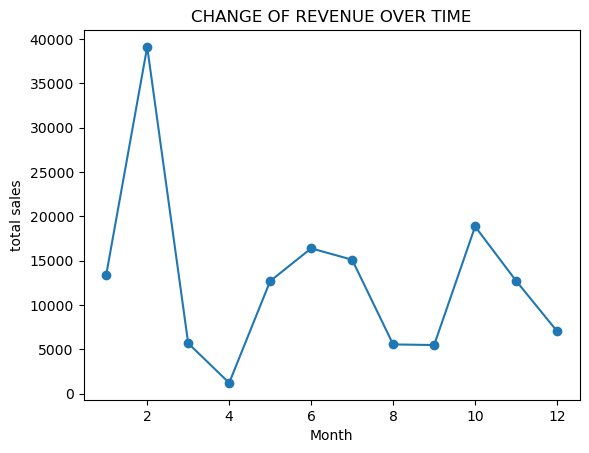

In [376]:

change_revenue = df.groupby("Month")["Total"].sum()
tot = change_revenue.values
month = change_revenue.index
plt.plot(month,tot, marker='o')
plt.xlabel("Month")
plt.ylabel("total sales")
plt.title("CHANGE OF REVENUE OVER TIME")
plt.show()

# PAYMENT METHOD USAGE 
### 4.How do most customers pay 

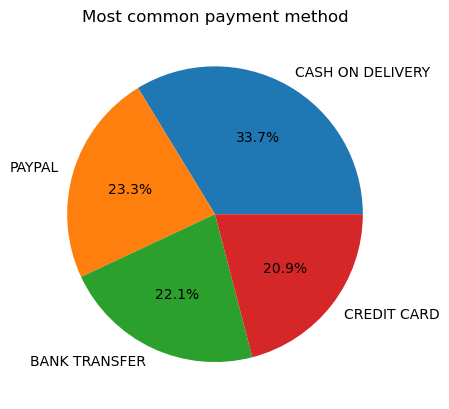

In [410]:
payment_count = df["Payment_Method"].value_counts()
ind_= payment_count.index

plt.pie(payment_count, labels = ind_, autopct="%1.1f%%")
plt.title("Most common payment method")
plt.show()

# ORDER STATUS 
### 5.WHAT'S HAPPENING TO THE ORDERS

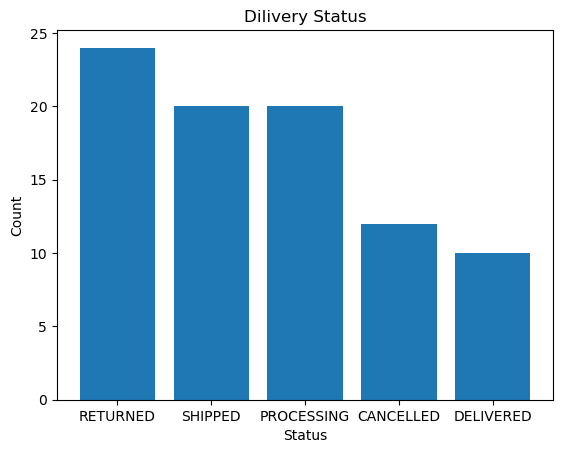

In [426]:
track_status = df["Status"].value_counts()
status = track_status.index
val_status = track_status.values

plt.bar(status, val_status)
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Dilivery Status")
plt.show()

# TOP SELLING PRODUCT 
### 6.Which product sells the most 

Text(0.5, 1.0, 'MOST SOLD PRODUCT')

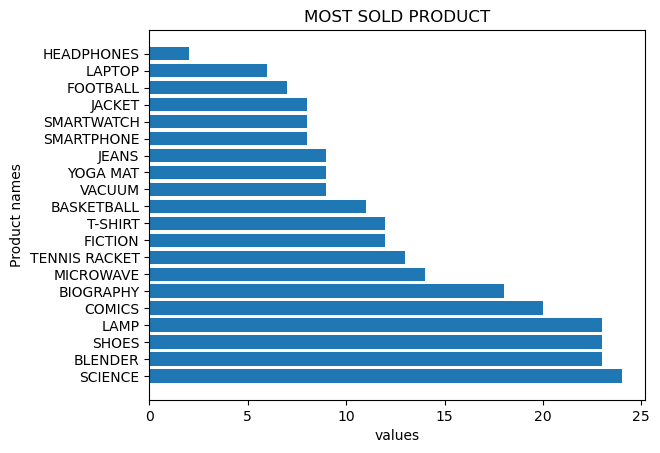

In [451]:
quantity= df.groupby("Product")["Quantity"].sum().sort_values(ascending = False)
prod_name = quantity.index
prod_quantity = quantity.values
plt.barh(prod_name, prod_quantity)
plt.xlabel("values")
plt.ylabel("Product names")
plt.title("MOST SOLD PRODUCT")

# REVENUE LOSS FROM RETURN 
### 7. how much money is lost from returned 

Text(0.5, 1.0, 'Total revenue vs lost revenue')

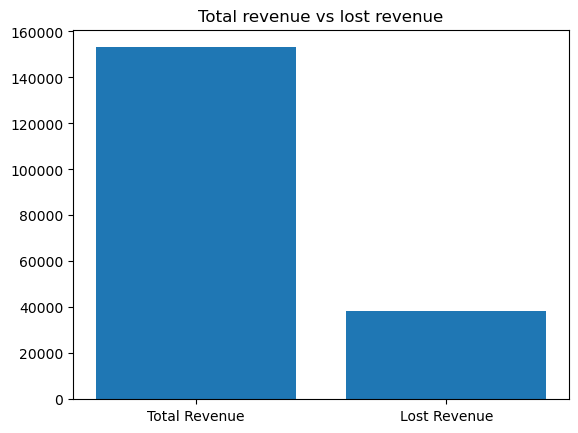

In [502]:
returned = df[df["Status"] =="RETURNED"]["Total"].sum()
total_ = df["Total"].sum()
plt.bar(["Total Revenue" , "Lost Revenue"], [total_, returned])
plt.title ("Total revenue vs lost revenue") 

# DISTRIBUTION OF TOTAL PRICES 
### 8. Are there outliers? Is the data skewed?


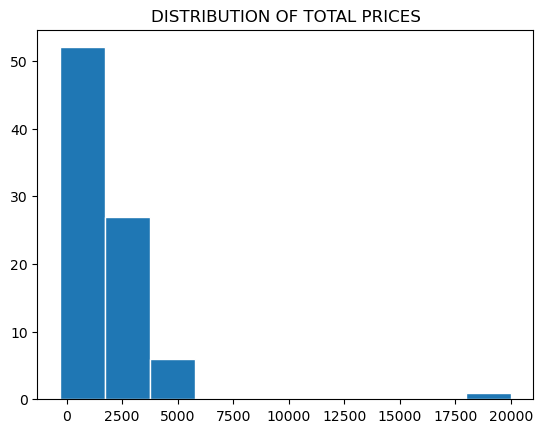

In [504]:
_tot_= df["Total"]
plt.hist(_tot_, edgecolor = "white")
plt.title("DISTRIBUTION OF TOTAL PRICES")
plt.show()